In [1]:
import os
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2

BASE_DIR = "/home/drivex/Ali/waymo_project"

INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'processed')

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Target Base: {BASE_DIR}")
print(f"Looking for data in: {INPUT_DIR}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

2026-04-15 20:56:14.449091: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 20:56:14.500304: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 20:56:14.851355: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/drivex/Ali/waymo_env/lib/python3.10/site-packages/nvidia/cudnn/lib:/home/drivex/Ali/waymo_en

Target Base: /home/drivex/Ali/waymo_project
Looking for data in: /home/drivex/Ali/waymo_project/data/raw
Num GPUs Available: 1


2026-04-15 20:56:15.355228: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-15 20:56:15.369225: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-15 20:56:15.371371: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [2]:
import glob
tfrecord_files = sorted(glob.glob(os.path.join(INPUT_DIR, '*.tfrecord*')))

if not tfrecord_files:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")

FILE_PATH = tfrecord_files[0]
dataset = tf.data.TFRecordDataset(FILE_PATH)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
print(f"Loaded Scenario: {scenario.scenario_id}")
print(f"Map Features: {len(scenario.map_features)} | Agents: {len(scenario.tracks)}")

2026-04-15 20:56:15.378384: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-15 20:56:15.379984: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-15 20:56:15.382136: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-15 20:56:15.383154: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at

Loaded Scenario: b85e1bd6cc8e74c0
Map Features: 139 | Agents: 14


In [3]:
import numpy as np
import math

def get_transform(ego_state):
    ref_x, ref_y = ego_state.center_x, ego_state.center_y
    rotation = -ego_state.heading
    return ref_x, ref_y, rotation

# Reference from Ego at Step 10
ego_track = scenario.tracks[scenario.sdc_track_index]
ref_x, ref_y, rot = get_transform(ego_track.states[10])

# Initialize Tensor [64 Agents, 91 Steps, 6 Features]
final_tensor = np.zeros((64, 91, 6), dtype=np.float32)


tracks_to_process = [ego_track] + [t for i, t in enumerate(scenario.tracks) if i != scenario.sdc_track_index]
tracks_to_process = tracks_to_process[:64]

for i, track in enumerate(tracks_to_process):
    for t, state in enumerate(track.states):
        if t >= 91: break
        if state.valid:
            # Translation
            dx, dy = state.center_x - ref_x, state.center_y - ref_y
            # Rotation
            nx = dx * math.cos(rot) - dy * math.sin(rot)
            ny = dx * math.sin(rot) + dy * math.cos(rot)
            
            final_tensor[i, t, :] = [nx, ny, state.velocity_x, state.velocity_y, float(track.object_type), 1.0]

save_name = f"processed_{scenario.scenario_id}.npy"
np.save(os.path.join(OUTPUT_DIR, save_name), final_tensor)

print(f"Tensor Created: {final_tensor.shape}")
print(f"Saved to: {os.path.join(OUTPUT_DIR, save_name)}")
print(f"Proof (Ego at Step 10): X={final_tensor[0,10,0]:.4f}, Y={final_tensor[0,10,1]:.4f}")

Tensor Created: (64, 91, 6)
Saved to: /home/drivex/Ali/waymo_project/data/processed/processed_b85e1bd6cc8e74c0.npy
Proof (Ego at Step 10): X=0.0000, Y=0.0000


In [4]:
import tensorflow as tf
from waymo_open_dataset.protos import scenario_pb2
import os
import glob

BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')

tfrecord_files = sorted(glob.glob(os.path.join(INPUT_DIR, '*.tfrecord*')))

if not tfrecord_files:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")

FILE_PATH = tfrecord_files[0]
dataset = tf.data.TFRecordDataset(FILE_PATH)
for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    print("SUCCESS! Scenario unpacked.\n")
    print(f"Scenario ID: {scenario.scenario_id}")
    print(f"Total time steps: {len(scenario.timestamps_seconds)} (91 steps = 9 seconds at 10Hz)")
    print(f"Number of agents (tracks) in this scene: {len(scenario.tracks)}")
    
    # first agent's trajectory!
    first_agent = scenario.tracks[0]
    print(f"\n--- First Agent Info ---")
    print(f"ID: {first_agent.id}")
    print(f"Type: {first_agent.object_type} (1=Vehicle, 2=Pedestrian, 3=Cyclist)") 
    
    
    print("\nFirst 5 X,Y coordinates of this agent:")
    for i in range(5):
        state = first_agent.states[i]
        # Waymo marks invalid states with valid=False
        if state.valid:
            print(f"Time Step {i}: X = {state.center_x:.2f}, Y = {state.center_y:.2f}, Speed = {state.velocity_x:.2f} m/s")
        else:
            print(f"Time Step {i}: [Agent not visible in this frame]")




# static map - Polylines
    print(f"\n--- Map Features (Polylines) ---")
    print(f"Total map features (lanes, crosswalks, stop signs) in this scene: {len(scenario.map_features)}")
    
    for i in range(3):
        feature = scenario.map_features[i]
        
        feature_type = feature.WhichOneof("feature_data")
        print(f"\nFeature {i}: Type = {feature_type}")
        
        # extract its mathematical shape
        if feature_type == 'lane':
            lane_polyline = feature.lane.polyline
            print(f"  This lane is made of {len(lane_polyline)} mathematical points.")
            print(f"  Start coordinate: X = {lane_polyline[0].x:.2f}, Y = {lane_polyline[0].y:.2f}")
            print(f"  End coordinate:   X = {lane_polyline[-1].x:.2f}, Y = {lane_polyline[-1].y:.2f}")

SUCCESS! Scenario unpacked.

Scenario ID: b85e1bd6cc8e74c0
Total time steps: 91 (91 steps = 9 seconds at 10Hz)
Number of agents (tracks) in this scene: 14

--- First Agent Info ---
ID: 1807
Type: 1 (1=Vehicle, 2=Pedestrian, 3=Cyclist)

First 5 X,Y coordinates of this agent:
Time Step 0: X = 3578.35, Y = 4986.54, Speed = 1.09 m/s
Time Step 1: X = 3578.46, Y = 4984.41, Speed = 1.11 m/s
Time Step 2: X = 3578.58, Y = 4982.28, Speed = 1.24 m/s
Time Step 3: X = 3578.71, Y = 4980.16, Speed = 1.24 m/s
Time Step 4: X = 3578.83, Y = 4978.03, Speed = 1.27 m/s

--- Map Features (Polylines) ---
Total map features (lanes, crosswalks, stop signs) in this scene: 139

Feature 0: Type = road_line

Feature 1: Type = road_line

Feature 2: Type = road_line


In [5]:
print(f"--- Map Features (Polylines) ---")
print(f"Total map features in this scene: {len(scenario.map_features)}")

# first 10 map features & their coordinates
for i in range(10):
    feature = scenario.map_features[i]
    feature_type = feature.WhichOneof("feature_data")
    
    print(f"\nFeature {i}: Type = {feature_type}")
    
    # polyline data
    polyline = None
    if feature_type == 'lane':
        polyline = feature.lane.polyline
    elif feature_type == 'road_line':
        polyline = feature.road_line.polyline
    elif feature_type == 'road_edge':
        polyline = feature.road_edge.polyline
    elif feature_type == 'crosswalk':
        # Crosswalks('polygon') - instead of 'polyline'
        polyline = feature.crosswalk.polygon 
        
    # print the start and end!
    if polyline and len(polyline) > 0:
        print(f"  -> Made of {len(polyline)} mathematical points (nodes).")
        print(f"  -> Start coordinate: X = {polyline[0].x:.2f}, Y = {polyline[0].y:.2f}")
        print(f"  -> End coordinate:   X = {polyline[-1].x:.2f}, Y = {polyline[-1].y:.2f}")

--- Map Features (Polylines) ---
Total map features in this scene: 139

Feature 0: Type = road_line
  -> Made of 1133 mathematical points (nodes).
  -> Start coordinate: X = 3574.94, Y = 5287.56
  -> End coordinate:   X = 3577.38, Y = 4725.79

Feature 1: Type = road_line
  -> Made of 1134 mathematical points (nodes).
  -> Start coordinate: X = 3578.29, Y = 5287.75
  -> End coordinate:   X = 3580.80, Y = 4725.70

Feature 2: Type = road_line
  -> Made of 490 mathematical points (nodes).
  -> Start coordinate: X = 3585.07, Y = 5287.57
  -> End coordinate:   X = 3586.15, Y = 5044.85

Feature 3: Type = road_edge
  -> Made of 534 mathematical points (nodes).
  -> Start coordinate: X = 3570.62, Y = 5287.70
  -> End coordinate:   X = 3571.71, Y = 5025.54

Feature 4: Type = road_line
  -> Made of 489 mathematical points (nodes).
  -> Start coordinate: X = 3582.54, Y = 5044.88
  -> End coordinate:   X = 3581.61, Y = 5287.92

Feature 5: Type = road_line
  -> Made of 560 mathematical points (nodes

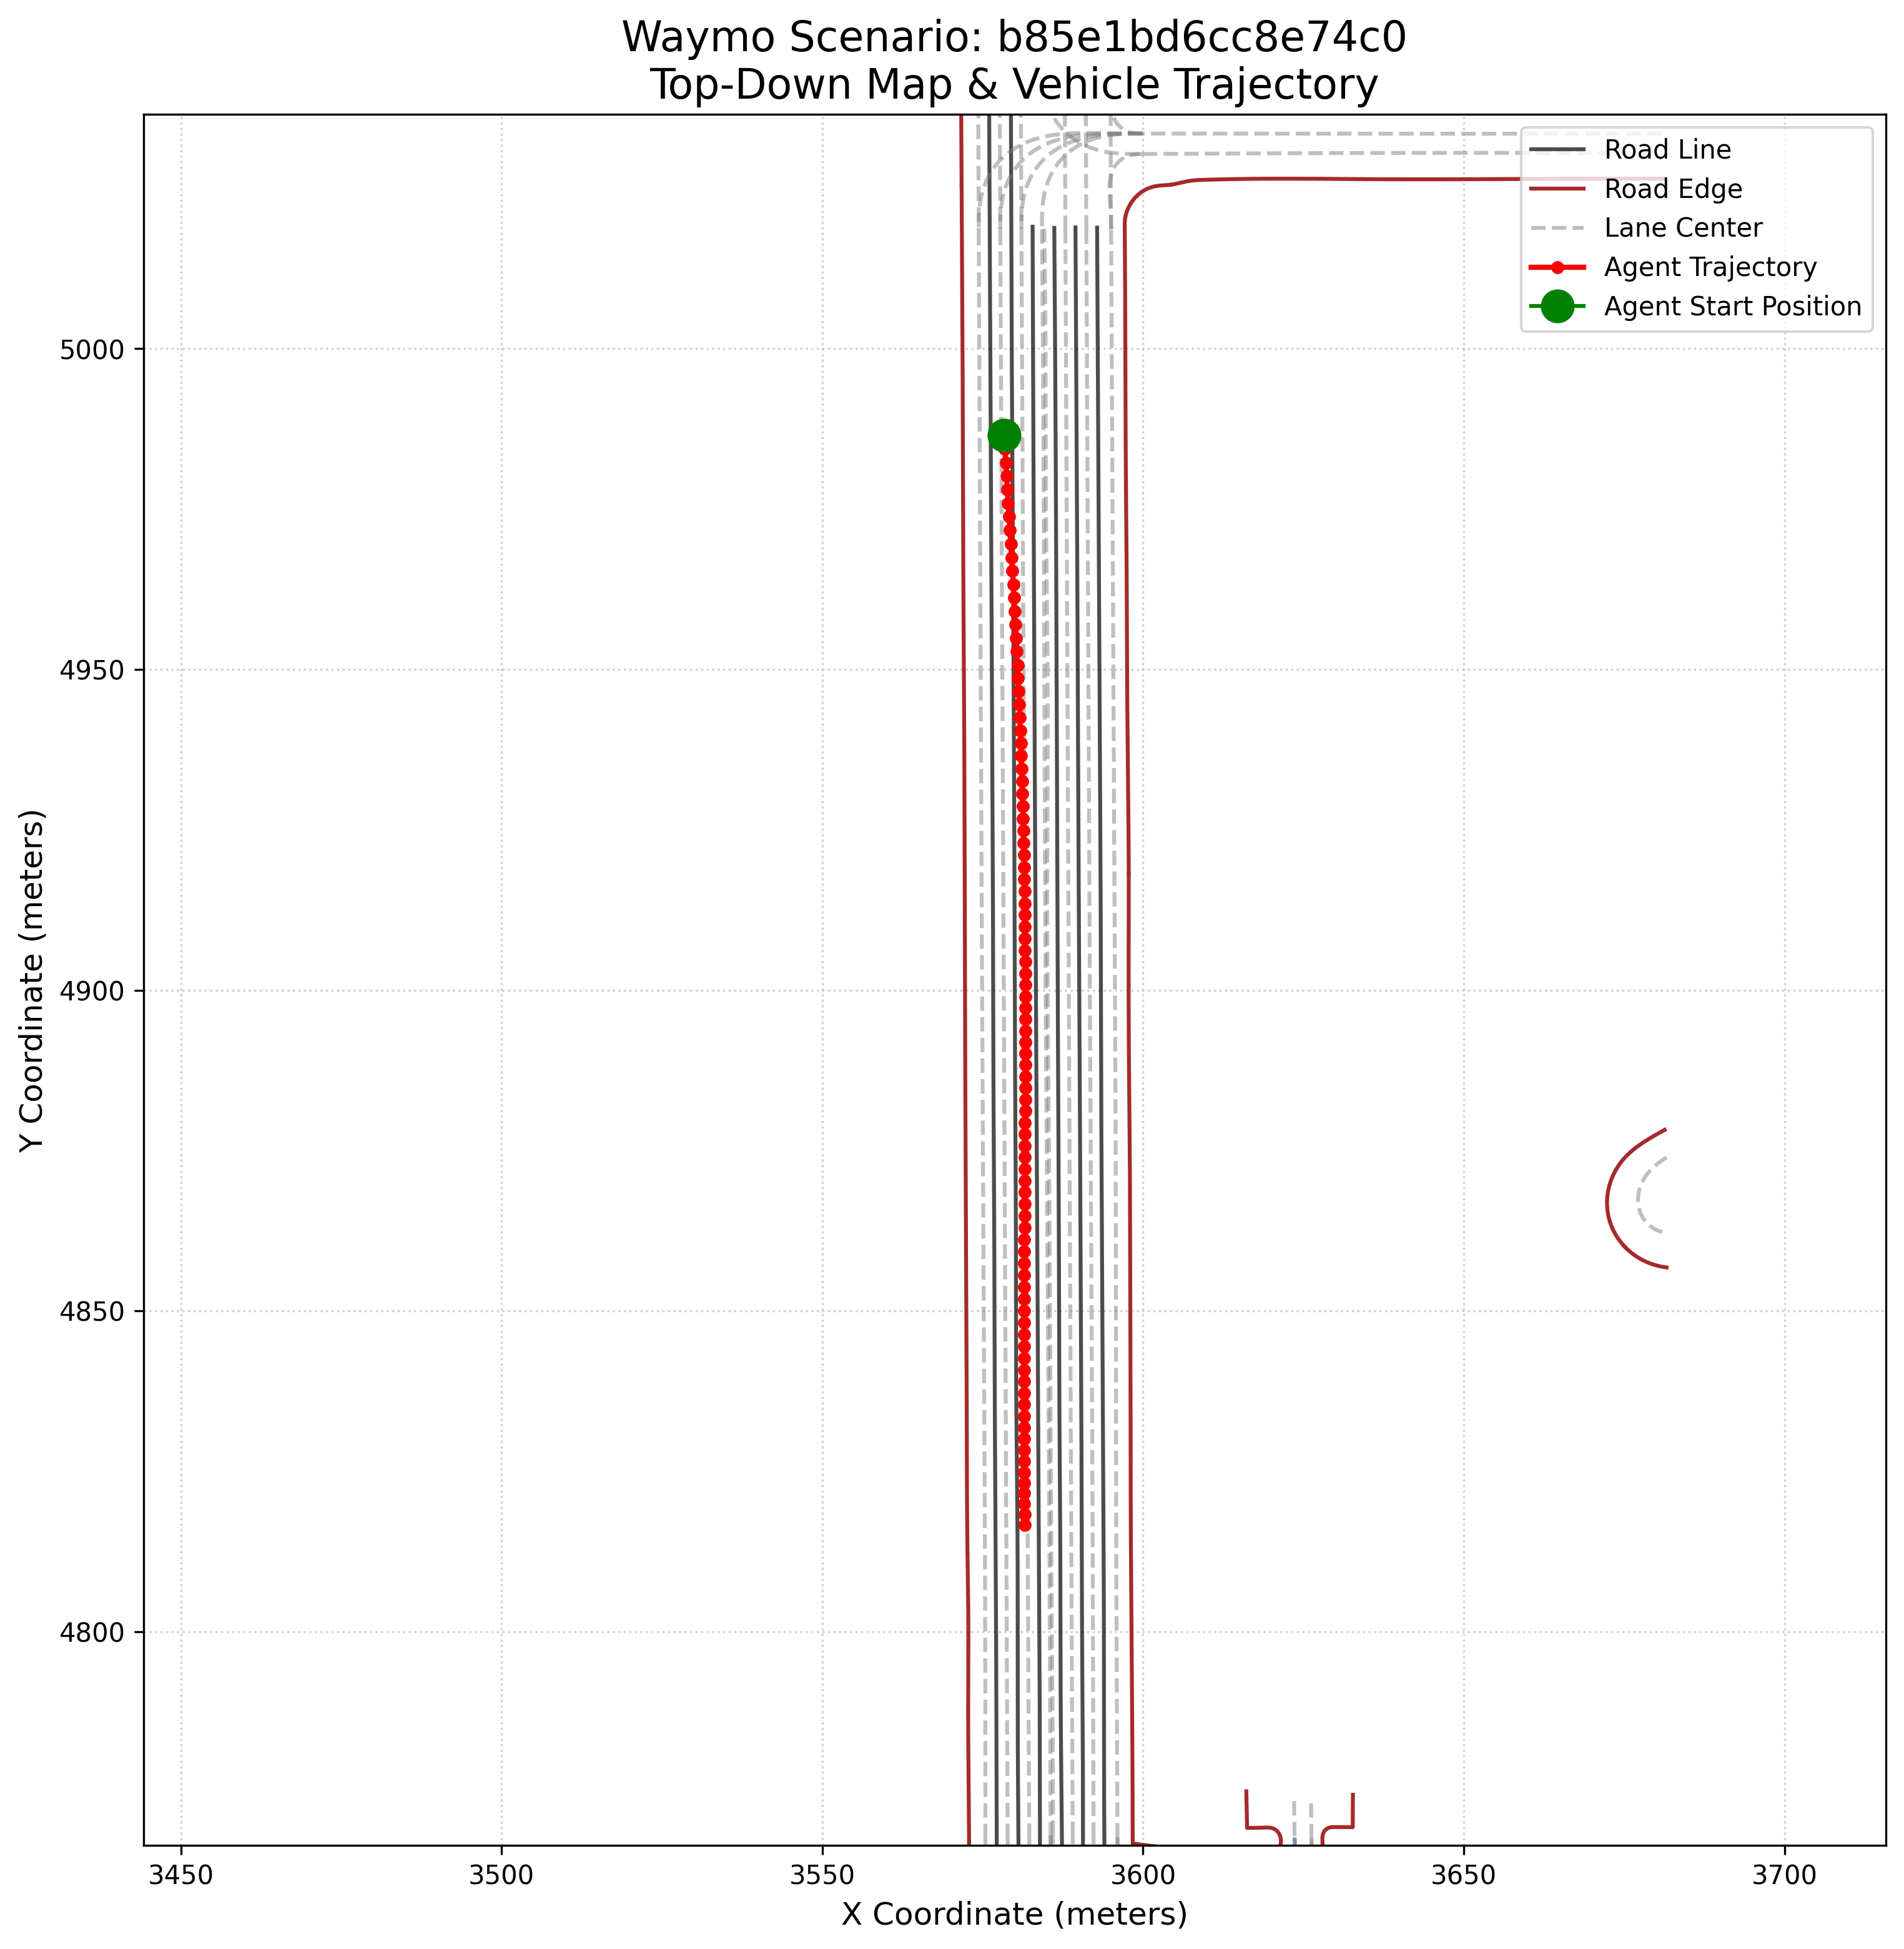

In [6]:
import matplotlib.pyplot as plt
from IPython.display import Image

plt.figure(figsize=(12, 12))
plt.title(f"Waymo Scenario: {scenario.scenario_id}\nTop-Down Map & Vehicle Trajectory", fontsize=16)

labels_added = {'lane': False, 'road_line': False, 'road_edge': False, 'crosswalk': False}

# Plot the Environment!
for feature in scenario.map_features:
    feature_type = feature.WhichOneof("feature_data")
    
    # Extract X and Y coordinates for polyline/polygon(s)
    if feature_type == 'lane':
        pts = feature.lane.polyline
        style, color, alpha, label_name = '--', 'gray', 0.5, 'Lane Center'
    elif feature_type == 'road_line':
        pts = feature.road_line.polyline
        style, color, alpha, label_name = '-', 'black', 0.7, 'Road Line'
    elif feature_type == 'road_edge':
        pts = feature.road_edge.polyline
        style, color, alpha, label_name = '-', 'brown', 1.0, 'Road Edge'
    elif feature_type == 'crosswalk':
        pts = feature.crosswalk.polygon
        style, color, alpha, label_name = '-', 'blue', 0.4, 'Crosswalk'
    else:
        continue
     # Skip other features for now
        
    if len(pts) > 0:
        x = [p.x for p in pts]
        y = [p.y for p in pts]
        
        label = label_name if not labels_added[feature_type] else ""
        labels_added[feature_type] = True
        
        plt.plot(x, y, linestyle=style, color=color, alpha=alpha, label=label, linewidth=1.5)

first_agent = scenario.tracks[0]
agent_x = []
agent_y = []

for state in first_agent.states:
    if state.valid: 
        agent_x.append(state.center_x)
        agent_y.append(state.center_y)

if len(agent_x) > 0:

    plt.plot(agent_x, agent_y, color='red', marker='.', linestyle='-', linewidth=2, markersize=8, label='Agent Trajectory')
    plt.plot(agent_x[0], agent_y[0], color='green', marker='o', markersize=12, label='Agent Start Position')

plt.axis('equal') # no stretching!
plt.xlabel("X Coordinate (meters)", fontsize=12)
plt.ylabel("Y Coordinate (meters)", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlim(min(agent_x) - 50, max(agent_x) + 50)
plt.ylim(min(agent_y) - 50, max(agent_y) + 50)

plt.savefig('waymo_intersection.png', dpi=300, bbox_inches='tight')
plt.close() # Close the buggy plot window

Image('waymo_intersection.png')

In [7]:
import tensorflow as tf
import glob
import math
from waymo_open_dataset.protos import scenario_pb2

# file_pattern = 'validation.tfrecord-*-of-00150'
# file_paths = sorted(glob.glob(file_pattern))[:50] 
BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
file_pattern = os.path.join(INPUT_DIR, '*.tfrecord*')
file_paths = sorted(glob.glob(file_pattern))[:50]
if not file_paths:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")


print(f"Found {len(file_paths)} files to analyze.")

dataset = tf.data.TFRecordDataset(file_paths)

total_scenarios_analyzed = 0
dangerous_interactions = 0

for data in dataset.take(200):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    total_scenarios_analyzed += 1
    
    sdc_index = scenario.sdc_track_index
    ego_vehicle = scenario.tracks[sdc_index]
    
    pedestrians = [track for track in scenario.tracks if track.object_type == 2] # 2 = Pedestrian
    
    interaction_found = False
    
    for step in range(len(scenario.timestamps_seconds)):
        
        ego_state = ego_vehicle.states[step]
        if not ego_state.valid:
            continue 
            
        ego_x, ego_y = ego_state.center_x, ego_state.center_y
        
        for ped in pedestrians:
            ped_state = ped.states[step]
            if not ped_state.valid:
                continue
                
            ped_x, ped_y = ped_state.center_x, ped_state.center_y
            
            distance = math.hypot(ego_x - ped_x, ego_y - ped_y)
            
            if distance < 5.0:
                interaction_found = True
                break 
                
        if interaction_found:
            dangerous_interactions += 1
            print(f"Close interaction found in Scenario: {scenario.scenario_id} (Distance: {distance:.2f}m)")
            break 

print("-" * 30)
print(f"Analysis Complete!")
print(f"Total Scenarios Analyzed: {total_scenarios_analyzed}")
print(f"Scenarios with Ego-Pedestrian close interactions (<5m): {dangerous_interactions}")

Found 50 files to analyze.
Close interaction found in Scenario: d4a4aac0a880c4a1 (Distance: 3.90m)
Close interaction found in Scenario: 5d3dd267ff0560f8 (Distance: 4.97m)
Close interaction found in Scenario: 137a96e2448a70f2 (Distance: 4.99m)
Close interaction found in Scenario: 3eea09dc81191856 (Distance: 4.28m)
Close interaction found in Scenario: afaaf8c731b424b0 (Distance: 4.89m)
Close interaction found in Scenario: 3269bc19bf1bd1e1 (Distance: 4.91m)


Close interaction found in Scenario: 1333a8922dc53f35 (Distance: 4.94m)
Close interaction found in Scenario: 1baa4c789d1ac747 (Distance: 4.96m)
Close interaction found in Scenario: 796e278d09e7c5e6 (Distance: 3.53m)
Close interaction found in Scenario: 797779c184e54223 (Distance: 4.97m)
Close interaction found in Scenario: 262112a66742fe8d (Distance: 4.56m)
------------------------------
Analysis Complete!
Total Scenarios Analyzed: 200
Scenarios with Ego-Pedestrian close interactions (<5m): 11


Hunting for Scenario 796e278d09e7c5e6...
Scenario Found! Generating Map...


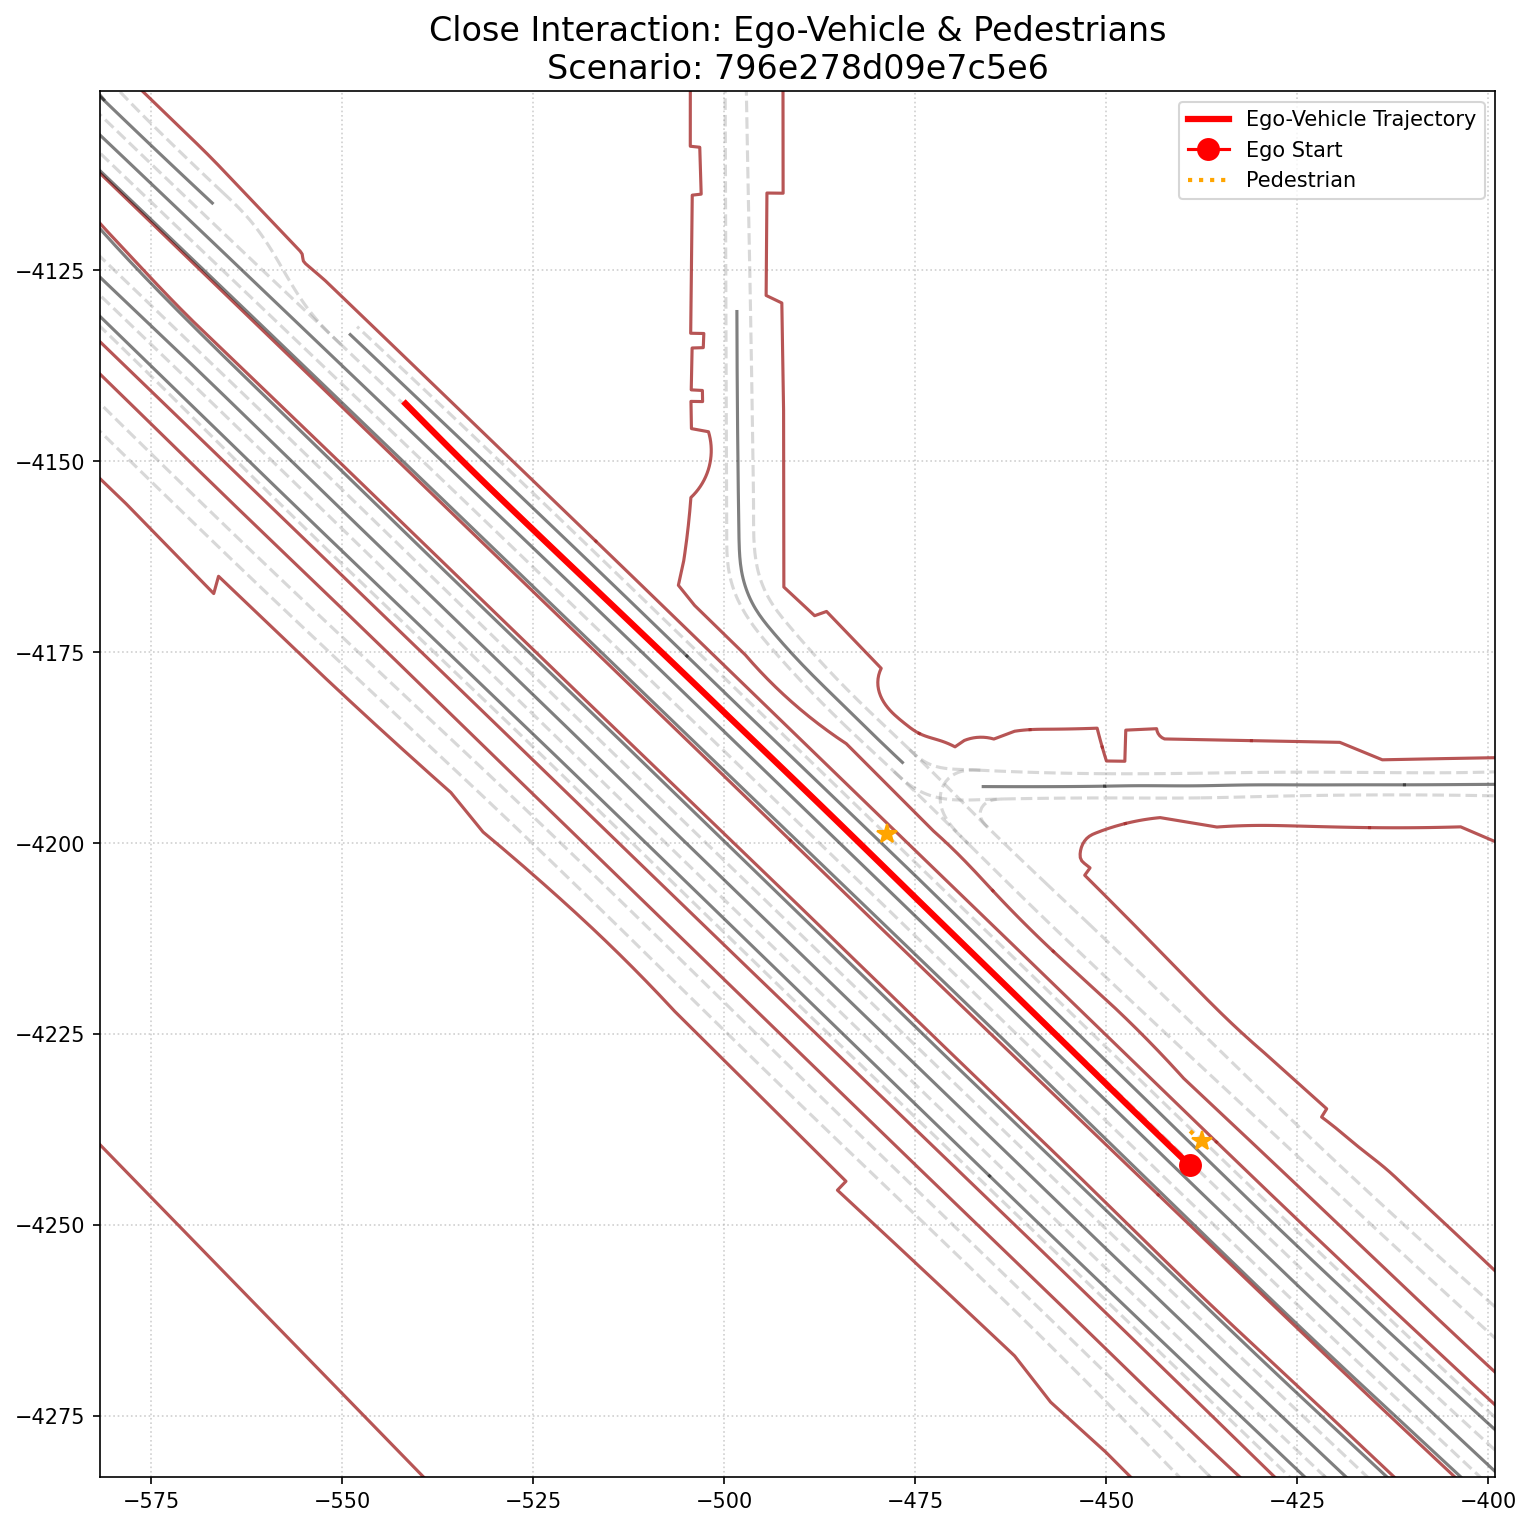

In [18]:
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
from IPython.display import Image, display
from waymo_open_dataset.protos import scenario_pb2

TARGET_SCENARIO_ID = '796e278d09e7c5e6' 
BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
file_pattern = os.path.join(INPUT_DIR, '*.tfrecord*')

file_paths = sorted(glob.glob(file_pattern))[:50]

if not file_paths:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")

dataset = tf.data.TFRecordDataset(file_paths)

# file_pattern = 'validation.tfrecord-*-of-00150'
# file_paths = sorted(glob.glob(file_pattern))[:50]
# dataset = tf.data.TFRecordDataset(file_paths)

print(f"Hunting for Scenario {TARGET_SCENARIO_ID}...")

target_scenario = None
for data in dataset.take(200):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    if scenario.scenario_id == TARGET_SCENARIO_ID:
        target_scenario = scenario
        print("Scenario Found! Generating Map...")
        break

if target_scenario:

    plt.figure(figsize=(12, 12))
    plt.title(f"Close Interaction: Ego-Vehicle & Pedestrians\nScenario: {target_scenario.scenario_id}", fontsize=16)

    for feature in target_scenario.map_features:
        feature_type = feature.WhichOneof("feature_data")
        if feature_type == 'lane':
            pts = feature.lane.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '--', color='gray', alpha=0.3)
        elif feature_type == 'road_line':
            pts = feature.road_line.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='black', alpha=0.5)
        elif feature_type == 'road_edge':
            pts = feature.road_edge.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='brown', alpha=0.8)
        elif feature_type == 'crosswalk':
            pts = feature.crosswalk.polygon
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='blue', alpha=0.4)

    ego = target_scenario.tracks[target_scenario.sdc_track_index]
    ego_x = [s.center_x for s in ego.states if s.valid]
    ego_y = [s.center_y for s in ego.states if s.valid]
    plt.plot(ego_x, ego_y, color='red', linewidth=3, label='Ego-Vehicle Trajectory')
    plt.plot(ego_x[0], ego_y[0], color='red', marker='o', markersize=10, label='Ego Start')

    pedestrians = [t for t in target_scenario.tracks if t.object_type == 2]
    for i, ped in enumerate(pedestrians):
        ped_x = [s.center_x for s in ped.states if s.valid]
        ped_y = [s.center_y for s in ped.states if s.valid]
        if len(ped_x) > 0:
            label = 'Pedestrian' if i == 0 else "" # label the first one - for legend!
            plt.plot(ped_x, ped_y, color='orange', linewidth=2, linestyle=':', label=label)
            plt.plot(ped_x[0], ped_y[0], color='orange', marker='*', markersize=10)

    
    plt.axis('equal')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.xlim(min(ego_x) - 40, max(ego_x) + 40)
    plt.ylim(min(ego_y) - 40, max(ego_y) + 40)

    plt.savefig('close_interaction.png', dpi=150, bbox_inches='tight')
    plt.close()

    display(Image('close_interaction.png'))
else:
    print("Scenario not found in the first 200 records.")

Scanning dataset for pedestrian interactions...
Success! Found scenario 4d82fec943ddaa44 with 1 pedestrians.
Generating Behavioral Analysis Graph...


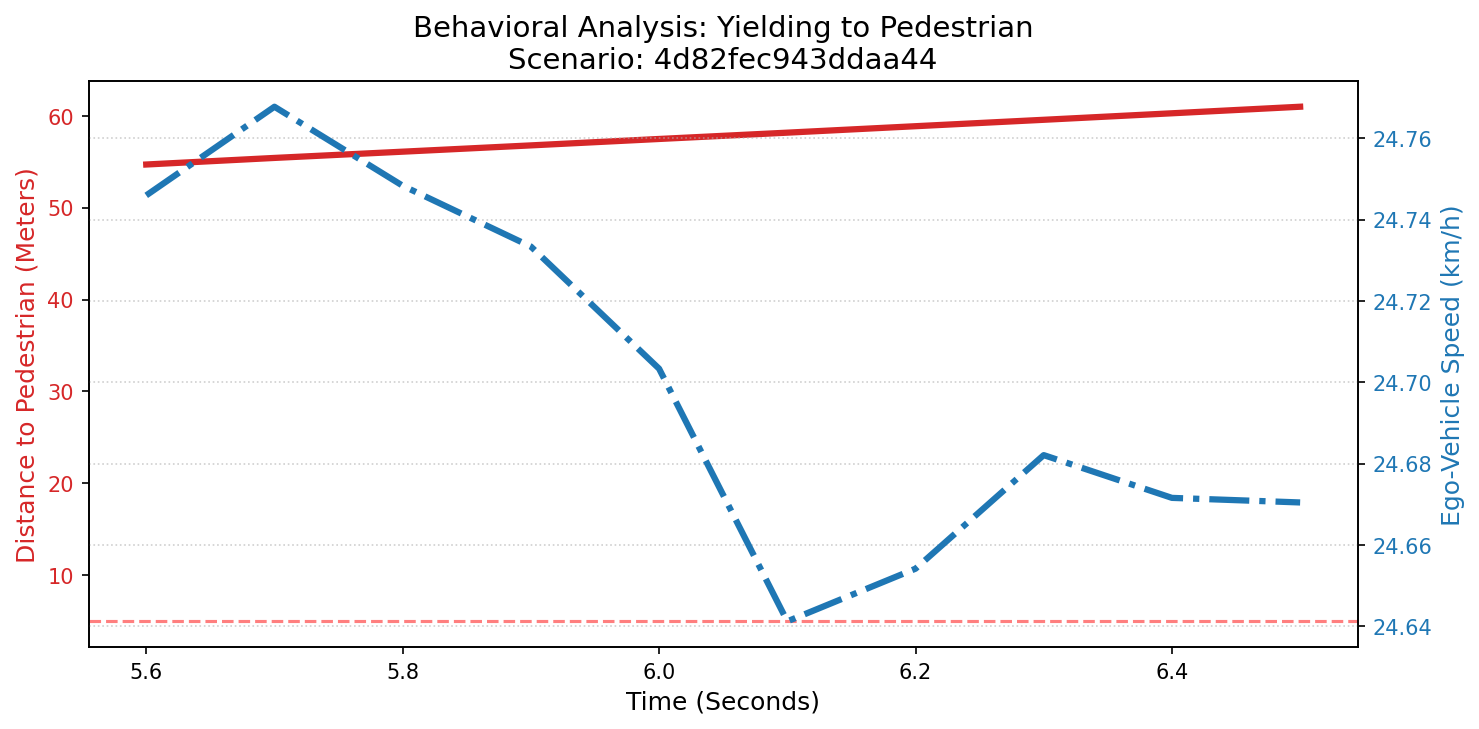

In [19]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import math
from IPython.display import Image, display
from waymo_open_dataset.protos import scenario_pb2

print("Scanning dataset for pedestrian interactions...")

target_scenario = None
pedestrians = []

for data in dataset.take(500):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    peds = [t for t in scenario.tracks if t.object_type == 2]
    if len(peds) > 0:
        target_scenario = scenario
        pedestrians = peds
        break

if target_scenario is None:
    print("Checked 500 scenarios. No pedestrians found in this specific file slice.")
else:
    print(f"Success! Found scenario {target_scenario.scenario_id} with {len(pedestrians)} pedestrians.")
    print("Generating Behavioral Analysis Graph...")

    ego_vehicle = target_scenario.tracks[target_scenario.sdc_track_index]
    closest_pedestrian = None
    min_dist_overall = 1000.0

    for ped in pedestrians:
        for step in range(91):
            if ego_vehicle.states[step].valid and ped.states[step].valid:
                dist = math.hypot(ego_vehicle.states[step].center_x - ped.states[step].center_x, 
                                  ego_vehicle.states[step].center_y - ped.states[step].center_y)
                if dist < min_dist_overall:
                    min_dist_overall = dist
                    closest_pedestrian = ped

    time_axis = []
    ego_speeds = []
    distances_to_ped = []

    for step in range(91):
        ego_state = ego_vehicle.states[step]
        ped_state = closest_pedestrian.states[step]
        
        if ego_state.valid and ped_state.valid:
            time_axis.append(step * 0.1)
            
            speed_ms = math.hypot(ego_state.velocity_x, ego_state.velocity_y)
            speed_kmh = speed_ms * 3.6 
            ego_speeds.append(speed_kmh)
            
            distance = math.hypot(ego_state.center_x - ped_state.center_x, 
                                  ego_state.center_y - ped_state.center_y)
            distances_to_ped.append(distance)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    plt.title(f"Behavioral Analysis: Yielding to Pedestrian\nScenario: {target_scenario.scenario_id}", fontsize=14)

    color = 'tab:red'
    ax1.set_xlabel('Time (Seconds)', fontsize=12)
    ax1.set_ylabel('Distance to Pedestrian (Meters)', color=color, fontsize=12)
    ax1.plot(time_axis, distances_to_ped, color=color, linewidth=3, label='Distance (m)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.axhline(y=5.0, color='red', linestyle='--', alpha=0.5, label='Danger Zone (< 5m)')

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('Ego-Vehicle Speed (km/h)', color=color, fontsize=12)
    ax2.plot(time_axis, ego_speeds, color=color, linewidth=3, linestyle='-.', label='Speed (km/h)')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.savefig('behavior_analysis.png', dpi=150, bbox_inches='tight')
    plt.close()

    display(Image('behavior_analysis.png'))

Hunting for a complex intersection (searching up to 20000 scenarios)...
Complex Intersection Found at scenario #2!
   Scenario ID: 4d82fec943ddaa44
   Features: 0 Crosswalks, 7 Stop Signs.


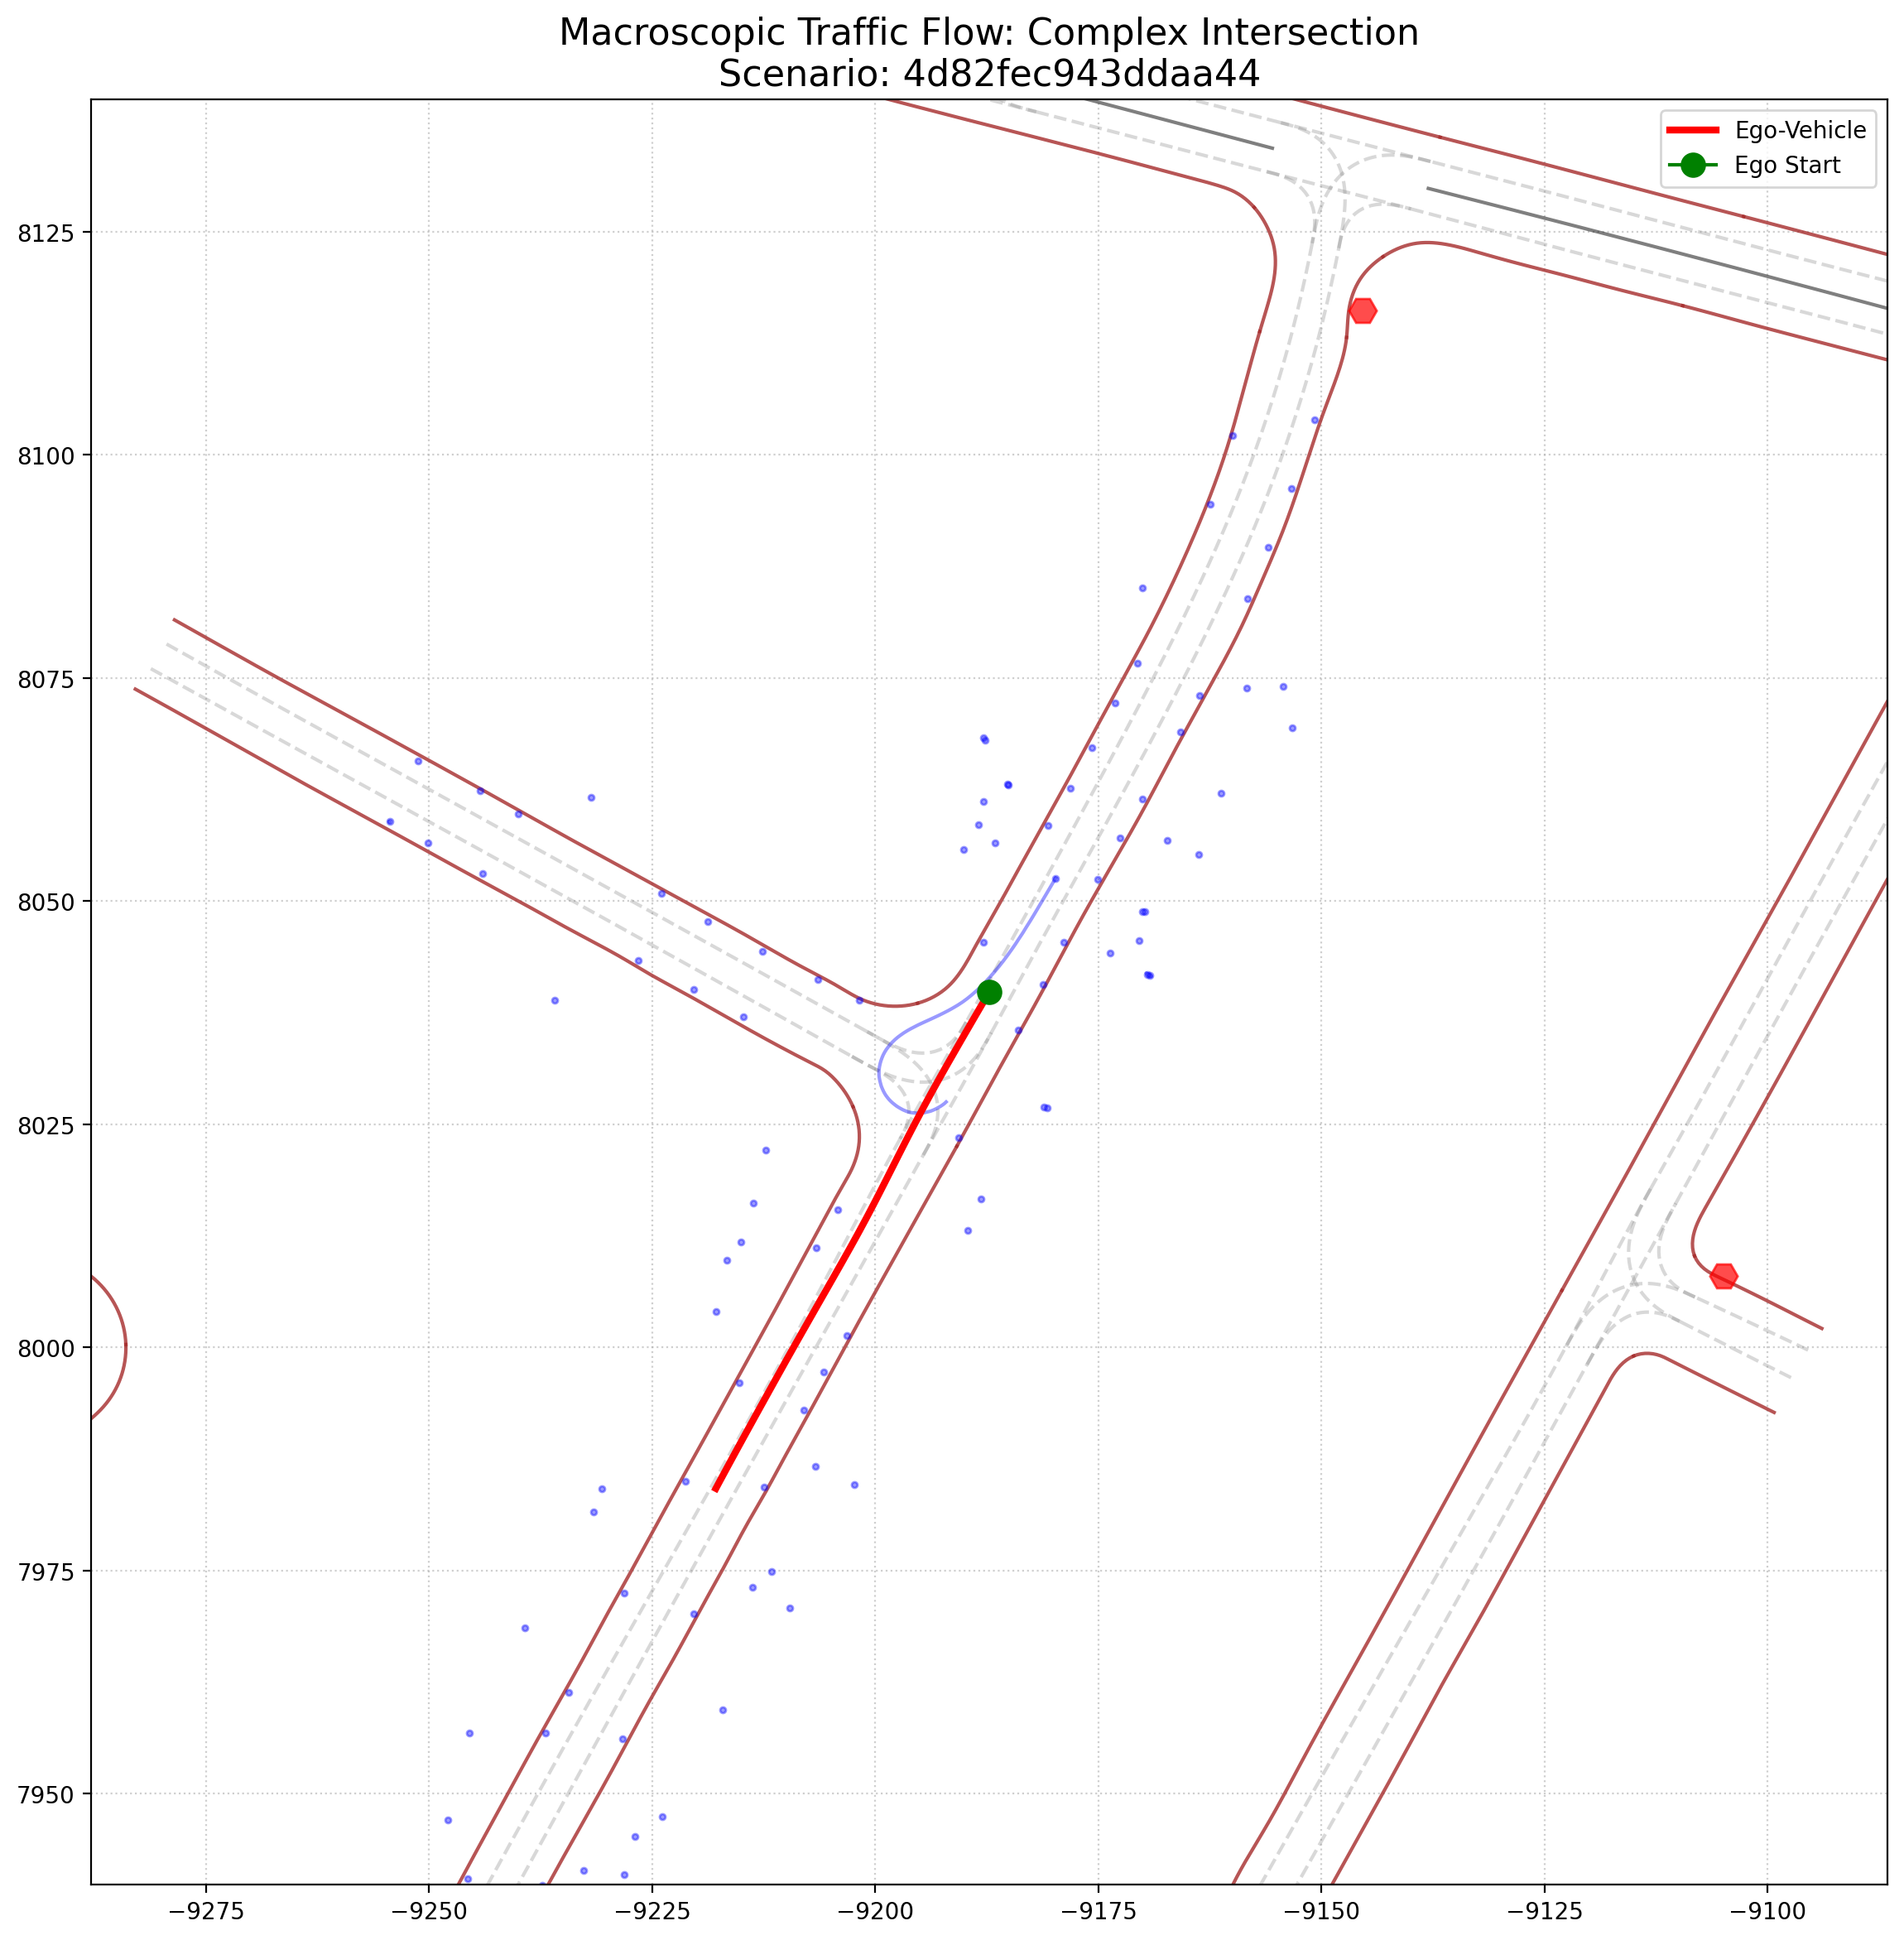

In [22]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
from IPython.display import Image, display
from waymo_open_dataset.protos import scenario_pb2

# file_pattern = 'validation.tfrecord-*-of-00150'
# file_paths = sorted(glob.glob(file_pattern))[:50]

BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
file_pattern = os.path.join(INPUT_DIR, '*.tfrecord*')
file_paths = sorted(glob.glob(file_pattern))[:50]
dataset = tf.data.TFRecordDataset(file_paths)

print("Hunting for a complex intersection (searching up to 20000 scenarios)...")

target_scenario = None
scenarios_checked = 0

for data in dataset.take(20000):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    scenarios_checked += 1
    
    crosswalk_count = 0
    stop_sign_count = 0
    
    for feature in scenario.map_features:
        feat_type = feature.WhichOneof("feature_data")
        if feat_type == 'crosswalk':
            crosswalk_count += 1
        elif feat_type == 'stop_sign':
            stop_sign_count += 1
            
    # searching for complex scenarios: >= (3 crosswalks / 4 stop signs)
    if crosswalk_count >= 3 or stop_sign_count >= 4:
        target_scenario = scenario
        print(f"Complex Intersection Found at scenario #{scenarios_checked}!")
        print(f"   Scenario ID: {scenario.scenario_id}")
        print(f"   Features: {crosswalk_count} Crosswalks, {stop_sign_count} Stop Signs.")
        break

if target_scenario:
    plt.figure(figsize=(14, 14))
    plt.title(f"Macroscopic Traffic Flow: Complex Intersection\nScenario: {target_scenario.scenario_id}", fontsize=16)

    for feature in target_scenario.map_features:
        feat_type = feature.WhichOneof("feature_data")
        if feat_type == 'lane':
            pts = feature.lane.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '--', color='gray', alpha=0.3)
        elif feat_type == 'road_line':
            pts = feature.road_line.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='black', alpha=0.5)
        elif feat_type == 'road_edge':
            pts = feature.road_edge.polyline
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='brown', alpha=0.8)
        elif feat_type == 'crosswalk':
            pts = feature.crosswalk.polygon
            plt.plot([p.x for p in pts], [p.y for p in pts], '-', color='blue', alpha=0.2)
        elif feat_type == 'stop_sign':
            pos = feature.stop_sign.position
            plt.plot(pos.x, pos.y, marker='H', color='red', markersize=12, alpha=0.7)

    #  traffic flow
    for track in target_scenario.tracks:
        if track.object_type == 1: # 1 = Vehicle
            veh_x = [s.center_x for s in track.states if s.valid]
            veh_y = [s.center_y for s in track.states if s.valid]
            if len(veh_x) > 0:
                plt.plot(veh_x, veh_y, color='blue', linewidth=1.5, alpha=0.4)
                plt.plot(veh_x[0], veh_y[0], color='blue', marker='.', markersize=5, alpha=0.4) # Start point

    #  (Red) - Ego-Vehicle
    ego = target_scenario.tracks[target_scenario.sdc_track_index]
    ego_x = [s.center_x for s in ego.states if s.valid]
    ego_y = [s.center_y for s in ego.states if s.valid]
    plt.plot(ego_x, ego_y, color='red', linewidth=3, label='Ego-Vehicle')
    plt.plot(ego_x[0], ego_y[0], color='green', marker='o', markersize=10, label='Ego Start')

    plt.axis('equal')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.xlim(ego_x[0] - 100, ego_x[0] + 100)
    plt.ylim(ego_y[0] - 100, ego_y[0] + 100)

    plt.savefig('complex_intersection.png', dpi=200, bbox_inches='tight')
    plt.close()

    display(Image('complex_intersection.png'))
else:
    print("Could not find a complex intersection in the first 2000 scenarios. Try increasing the search limit!")

In [25]:
import os
import tensorflow as tf
import glob
from waymo_open_dataset.protos import scenario_pb2

BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')

tfrecord_files = sorted(glob.glob(os.path.join(INPUT_DIR, '*.tfrecord*')))
FILE_PATH = tfrecord_files[0]

dataset = tf.data.TFRecordDataset(FILE_PATH)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    print(f"=== SCENARIO METADATA ===")
    print(f"ID: {scenario.scenario_id}")
    print(f"Time steps: {len(scenario.timestamps_seconds)} (Each step is 0.1s)")
    print(f"Total Agents (Tracks): {len(scenario.tracks)}")
    print(f"Total Map Features: {len(scenario.map_features)}")
    print(f"Total Traffic Light States: {len(scenario.dynamic_map_states)}")
    
    print("\n=== AGENT (TRACK) PARAMETERS ===")
    sample_agent = scenario.tracks[0]
    print(f"Agent Type: {sample_agent.object_type} (1=Vehicle, 2=Pedestrian, 3=Cyclist)")
    print(f"Agent ID: {sample_agent.id}")
    
    print("\n=== EXACT KINEMATIC FEATURES (At Time Step 0) ===")
    sample_state = sample_agent.states[0]
    
    available_features = [f for f in dir(sample_state) if not f.startswith('_')]
    
    for feature in available_features:
        try:
            value = getattr(sample_state, feature)
            if isinstance(value, (int, float, bool)):
                print(f" - {feature}: {value}")
        except:
            pass

=== SCENARIO METADATA ===
ID: b85e1bd6cc8e74c0
Time steps: 91 (Each step is 0.1s)
Total Agents (Tracks): 14
Total Map Features: 139
Total Traffic Light States: 91

=== AGENT (TRACK) PARAMETERS ===
Agent Type: 1 (1=Vehicle, 2=Pedestrian, 3=Cyclist)
Agent ID: 1807

=== EXACT KINEMATIC FEATURES (At Time Step 0) ===
 - center_x: 3578.34912109375
 - center_y: 4986.5380859375
 - center_z: 31.326579674761483
 - heading: -1.5208313465118408
 - height: 1.691864013671875
 - length: 4.763912200927734
 - valid: True
 - velocity_x: 1.08642578125
 - velocity_y: -21.40625
 - width: 2.0494463443756104


Starting the Dataset Census (Analyzing up to 20000 scenarios)...
------------------------------
Total Scenarios Analyzed: 14717
Average Vehicles per Scenario: 59.3
Max Vehicles in one Scenario: 385
Average Pedestrians per Scenario: 7.5
Max Pedestrians in one Scenario: 322
------------------------------


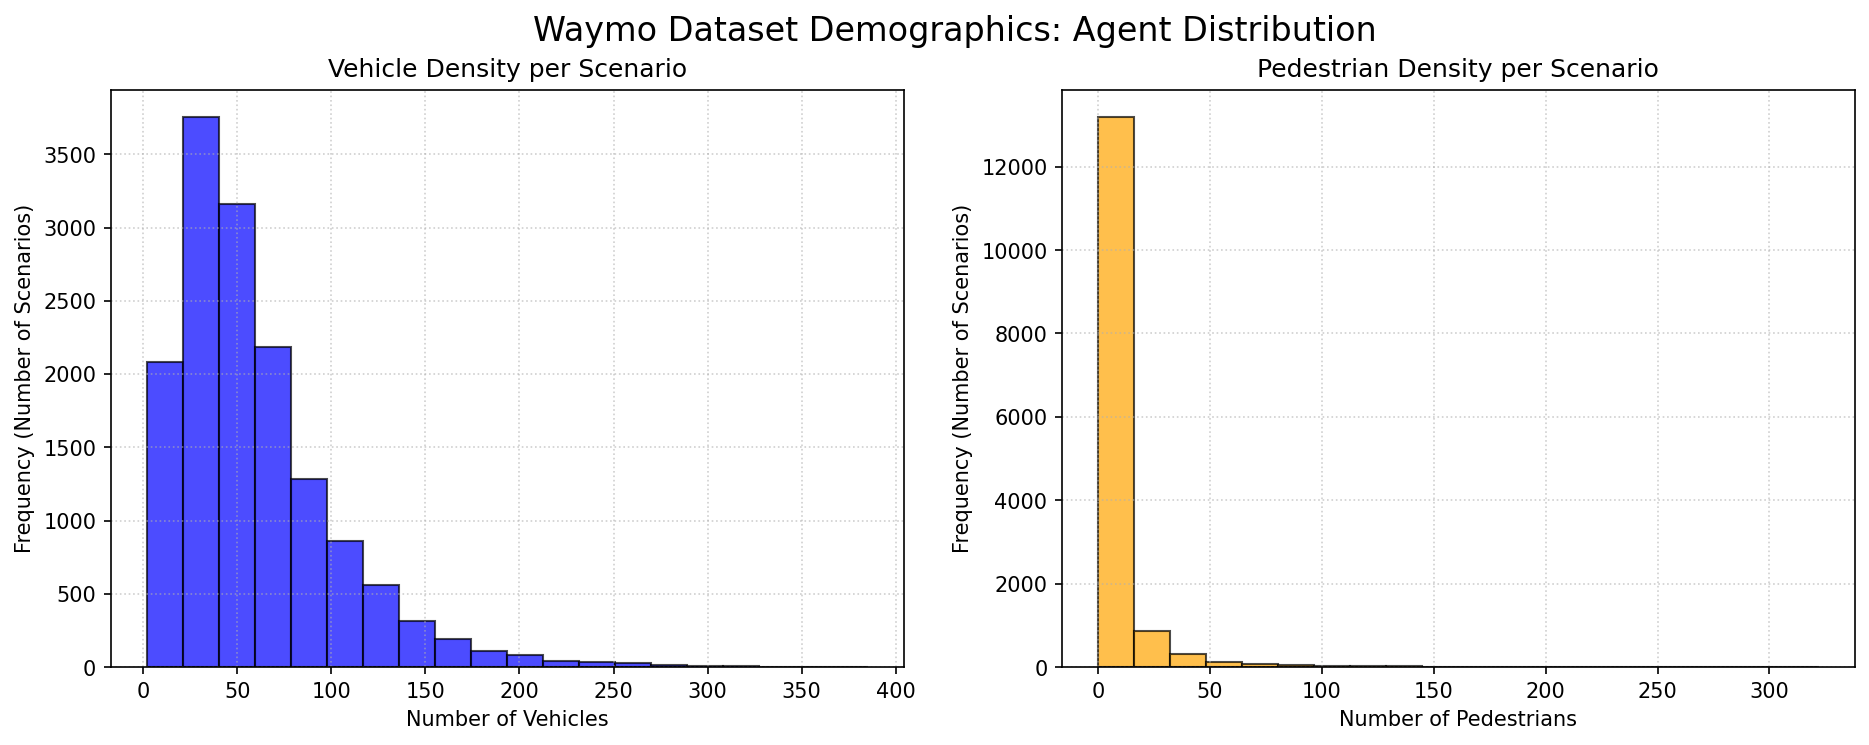

In [26]:
import os
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
import numpy as np
from waymo_open_dataset.protos import scenario_pb2
from IPython.display import Image, display

print("Starting the Dataset Census (Analyzing up to 20000 scenarios)...")

BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
file_pattern = os.path.join(INPUT_DIR, '*.tfrecord*')

file_paths = sorted(glob.glob(file_pattern))[:50]

if not file_paths:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")

dataset = tf.data.TFRecordDataset(file_paths)

vehicle_counts = []
pedestrian_counts = []
cyclist_counts = []

scenarios_analyzed = 0

for data in dataset.take(20000):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    scenarios_analyzed += 1
    
    v_count = 0
    p_count = 0
    c_count = 0
    
    for track in scenario.tracks:
        if track.object_type == 1:
            v_count += 1
        elif track.object_type == 2:
            p_count += 1
        elif track.object_type == 3:
            c_count += 1
            
    vehicle_counts.append(v_count)
    pedestrian_counts.append(p_count)
    cyclist_counts.append(c_count)

print("-" * 30)
print(f"Total Scenarios Analyzed: {scenarios_analyzed}")

if scenarios_analyzed > 0:
    print(f"Average Vehicles per Scenario: {np.mean(vehicle_counts):.1f}")
    print(f"Max Vehicles in one Scenario: {np.max(vehicle_counts)}")
    print(f"Average Pedestrians per Scenario: {np.mean(pedestrian_counts):.1f}")
    print(f"Max Pedestrians in one Scenario: {np.max(pedestrian_counts)}")
print("-" * 30)

if scenarios_analyzed > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Waymo Dataset Demographics: Agent Distribution", fontsize=16)

    ax1.hist(vehicle_counts, bins=20, color='blue', alpha=0.7, edgecolor='black')
    ax1.set_title("Vehicle Density per Scenario")
    ax1.set_xlabel("Number of Vehicles")
    ax1.set_ylabel("Frequency (Number of Scenarios)")
    ax1.grid(True, linestyle=':', alpha=0.6)

    ax2.hist(pedestrian_counts, bins=20, color='orange', alpha=0.7, edgecolor='black')
    ax2.set_title("Pedestrian Density per Scenario")
    ax2.set_xlabel("Number of Pedestrians")
    ax2.set_ylabel("Frequency (Number of Scenarios)")
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.savefig('dataset_census.png', dpi=150, bbox_inches='tight')
    plt.close()

    display(Image('dataset_census.png'))

Starting the Behavioral Motion Labeler...
behavior_labels: 
['Stationary', 'Cruising Straight', 'Turning/Lane Changing'],
[3275, 7493, 3949]


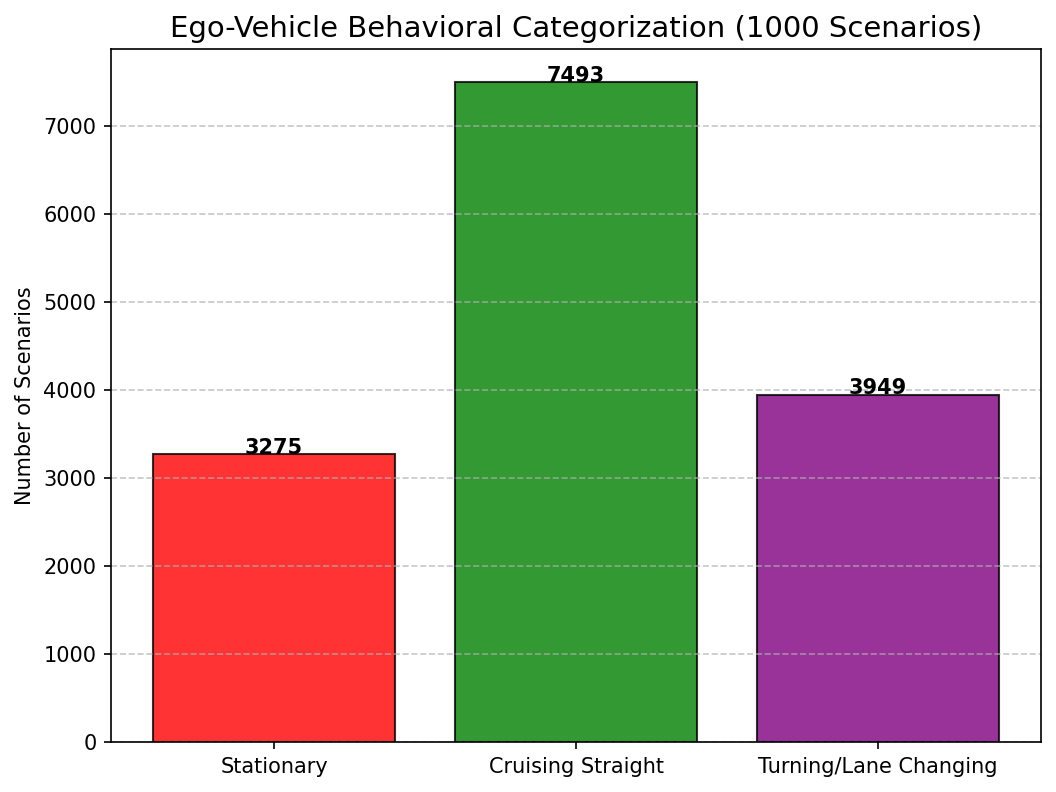

In [27]:
import math
import numpy as np

print("Starting the Behavioral Motion Labeler...")

behavior_labels = {"Stationary": 0, "Cruising Straight": 0, "Turning/Lane Changing": 0}

for data in dataset.take(20000):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    # Isolate the Ego-Vehicle
    ego = scenario.tracks[scenario.sdc_track_index]
    
    speeds = []
    headings = []
    
    # kinematics for 9-second window!
    for state in ego.states:
        if state.valid:
            speed = math.hypot(state.velocity_x, state.velocity_y)
            speeds.append(speed)
            headings.append(state.heading)
            
    # If missing data, skip this scenario
    if len(speeds) < 10:
        continue
        
    max_speed = np.max(speeds)
    
    heading_variance = np.max(headings) - np.min(headings)
    
    if max_speed < 1.0: 
        behavior_labels["Stationary"] += 1
    elif heading_variance > 0.15: # Rotated more than ~8.5 degrees!
        behavior_labels["Turning/Lane Changing"] += 1
    else:
        behavior_labels["Cruising Straight"] += 1

# Plot the Categorized Behaviors
labels = list(behavior_labels.keys())
counts = list(behavior_labels.values())
print(f"behavior_labels: \n{labels},\n{counts}")

plt.figure(figsize=(8, 6))
plt.bar(labels, counts, color=['red', 'green', 'purple'], alpha=0.8, edgecolor='black')
plt.title("Ego-Vehicle Behavioral Categorization (1000 Scenarios)", fontsize=14)
plt.ylabel("Number of Scenarios")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.savefig('behavior_labels.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image('behavior_labels.png'))

In [28]:
import tensorflow as tf

print("=== GPU Check ===")
gpus = tf.config.list_physical_devices('GPU')
print(f"Num GPUs Available: {len(gpus)}")

if len(gpus) > 0:
    for gpu in gpus:
        print(f"GPU Details: {gpu}")
else:
    print("TensorFlow is still only seeing the CPU!")

=== GPU Check ===
Num GPUs Available: 1
GPU Details: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Running Ego-Centric Normalization...
Original Ego Position: X=3581.41, Y=4977.78, Heading=-1.57 rad


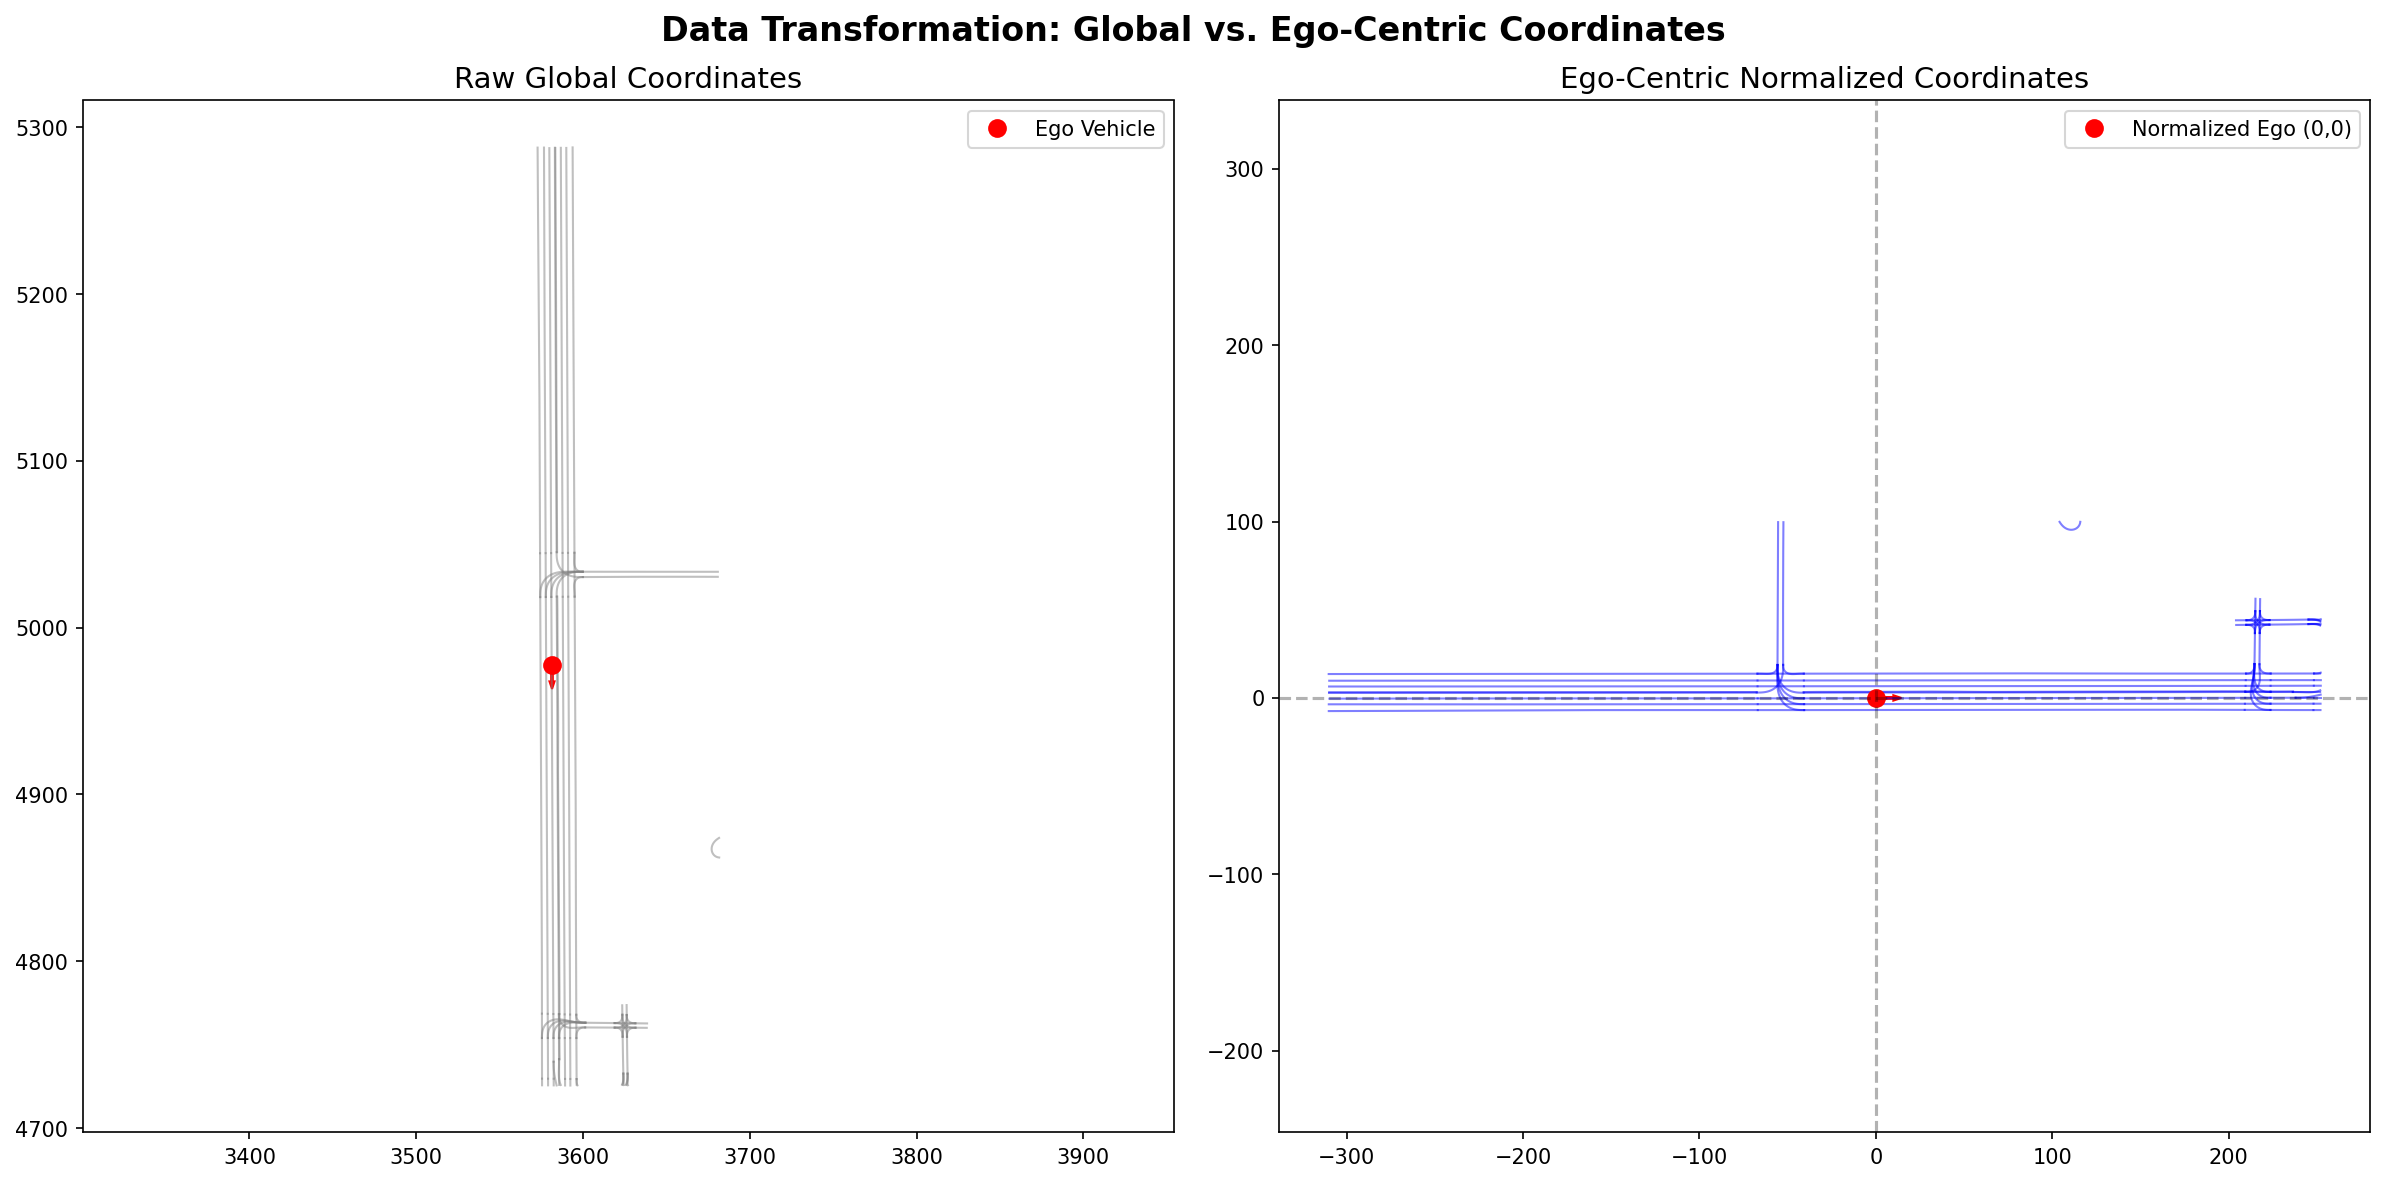

In [29]:
import os
import tensorflow as tf
import numpy as np
import math
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from waymo_open_dataset.protos import scenario_pb2
from IPython.display import Image, display
import glob

print("Running Ego-Centric Normalization...")

BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
file_pattern = os.path.join(INPUT_DIR, '*.tfrecord*')

file_paths = sorted(glob.glob(file_pattern))[:1]

if not file_paths:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")

dataset = tf.data.TFRecordDataset(file_paths)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    ego_track = scenario.tracks[scenario.sdc_track_index]
    ego_state = ego_track.states[10] 
    
    ego_x = ego_state.center_x
    ego_y = ego_state.center_y
    ego_heading = ego_state.heading 
    
    print(f"Original Ego Position: X={ego_x:.2f}, Y={ego_y:.2f}, Heading={ego_heading:.2f} rad")

    def normalize_point(x, y, ego_x, ego_y, ego_heading):
        dx = x - ego_x
        dy = y - ego_y
        cos_h = math.cos(-ego_heading)
        sin_h = math.sin(-ego_heading)
        
        norm_x = dx * cos_h - dy * sin_h
        norm_y = dx * sin_h + dy * cos_h
        return norm_x, norm_y

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle("Data Transformation: Global vs. Ego-Centric Coordinates", fontsize=16, fontweight='bold')

    for feature in scenario.map_features:
        if feature.HasField('lane'):
            global_x = [pt.x for pt in feature.lane.polyline]
            global_y = [pt.y for pt in feature.lane.polyline]
            ax1.plot(global_x, global_y, color='gray', linewidth=1, alpha=0.5)
            
            norm_points = [normalize_point(pt.x, pt.y, ego_x, ego_y, ego_heading) for pt in feature.lane.polyline]
            norm_x = [p[0] for p in norm_points]
            norm_y = [p[1] for p in norm_points]
            ax2.plot(norm_x, norm_y, color='blue', linewidth=1, alpha=0.5)

    ax1.plot(ego_x, ego_y, 'ro', markersize=8, label='Ego Vehicle')
    ax1.arrow(ego_x, ego_y, math.cos(ego_heading)*10, math.sin(ego_heading)*10, color='red', width=1)
    ax1.set_title("Raw Global Coordinates", fontsize=14)
    ax1.axis('equal')
    ax1.legend()

    ax2.plot(0, 0, 'ro', markersize=8, label='Normalized Ego (0,0)')
    ax2.arrow(0, 0, 10, 0, color='red', width=1) 
    ax2.set_title("Ego-Centric Normalized Coordinates", fontsize=14)
    ax2.axis('equal')
    ax2.legend()
    
    ax2.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax2.axvline(0, color='black', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('ego_centric_normalization.png', dpi=150, bbox_inches='tight')
    plt.close()

display(Image('ego_centric_normalization.png'))

In [31]:
import tensorflow as tf
import numpy as np
import math
import glob
from waymo_open_dataset.protos import scenario_pb2
import os

print("Building Deep Learning Tensors...")

MAX_AGENTS = 64
TIME_STEPS = 91
FEATURES = 6 

BASE_DIR = "/home/drivex/Ali/waymo_project"
INPUT_DIR = os.path.join(BASE_DIR, 'data', 'raw')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'processed')

file_pattern = os.path.join(INPUT_DIR, '*.tfrecord*')
file_paths = sorted(glob.glob(file_pattern))[:1]

if not file_paths:
    raise FileNotFoundError(f"No .tfrecord files found in {INPUT_DIR}")

dataset = tf.data.TFRecordDataset(file_paths)

for data in dataset.take(1):
    scenario = scenario_pb2.Scenario()
    scenario.ParseFromString(data.numpy())
    
    ego_track = scenario.tracks[scenario.sdc_track_index]
    ego_state = ego_track.states[10]
    
    ref_x = ego_state.center_x
    ref_y = ego_state.center_y
    ref_heading = ego_state.heading
    
    cos_h = math.cos(-ref_heading)
    sin_h = math.sin(-ref_heading)

    scenario_tensor = np.zeros((MAX_AGENTS, TIME_STEPS, FEATURES), dtype=np.float32)
    
    valid_tracks = [ego_track] + [t for i, t in enumerate(scenario.tracks) if i != scenario.sdc_track_index]
    valid_tracks = valid_tracks[:MAX_AGENTS]
    
    for agent_idx, track in enumerate(valid_tracks):
        agent_type = track.object_type 
        
        for t_idx, state in enumerate(track.states):
            if t_idx >= TIME_STEPS:
                break
                
            if state.valid:
                dx = state.center_x - ref_x
                dy = state.center_y - ref_y
                
                norm_x = dx * cos_h - dy * sin_h
                norm_y = dx * sin_h + dy * cos_h
                
                vx = state.velocity_x
                vy = state.velocity_y
                norm_vx = vx * cos_h - vy * sin_h
                norm_vy = vx * sin_h + vy * cos_h
                
                scenario_tensor[agent_idx, t_idx, 0] = norm_x
                scenario_tensor[agent_idx, t_idx, 1] = norm_y
                scenario_tensor[agent_idx, t_idx, 2] = norm_vx
                scenario_tensor[agent_idx, t_idx, 3] = norm_vy
                scenario_tensor[agent_idx, t_idx, 4] = float(agent_type)
                scenario_tensor[agent_idx, t_idx, 5] = 1.0 
                
    final_tf_tensor = tf.convert_to_tensor(scenario_tensor, dtype=tf.float32)
    
    print("-" * 40)
    print("SCENARIO TENSOR CREATED SUCCESSFULLY")
    print(f"Final Tensor Shape: {final_tf_tensor.shape}")
    print(f"Data Type: {final_tf_tensor.dtype}")
    print("-" * 40)
    
    print("\n🔍 Proof of Normalization (Ego at Step 10):")
    ego_t10 = final_tf_tensor[0, 10, :].numpy()
    print(f"X position: {ego_t10[0]:.4f} (Should be 0.0)")
    print(f"Y position: {ego_t10[1]:.4f} (Should be 0.0)")
    print(f"Agent Type: {ego_t10[4]} (1.0 = Vehicle)")
    print(f"Valid Mask: {ego_t10[5]} (1.0 = Data Exists)")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    save_path = os.path.join(OUTPUT_DIR, f"processed_{scenario.scenario_id}.npy")
    np.save(save_path, final_tf_tensor.numpy())

    print(f"Tensor saved permanently to: {save_path}")

Building Deep Learning Tensors...
----------------------------------------
SCENARIO TENSOR CREATED SUCCESSFULLY
Final Tensor Shape: (64, 91, 6)
Data Type: <dtype: 'float32'>
----------------------------------------

🔍 Proof of Normalization (Ego at Step 10):
X position: 0.0000 (Should be 0.0)
Y position: 0.0000 (Should be 0.0)
Agent Type: 1.0 (1.0 = Vehicle)
Valid Mask: 1.0 (1.0 = Data Exists)
Tensor saved permanently to: /home/drivex/Ali/waymo_project/data/processed/processed_b85e1bd6cc8e74c0.npy
